### Imports

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator 

# Results (copied straight from source code)

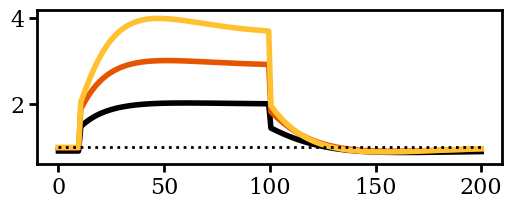

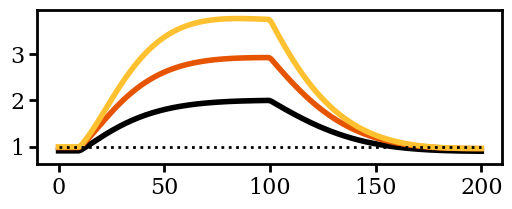

In [2]:
# for recreating figures from the paper with custom colours
T_PULSE_START = 10
T_PULSE_END = 100
T_MAX = 200
vline_timepoints = [(T_PULSE_START,'ONSET',3.5),(T_PULSE_END-2,'EW',3.5),(T_PULSE_END+30,'IW',3),(T_MAX-10,'LW',3.5)]
kGR=4

pars = dict([("gamma_h",np.log(2)/4),("gamma_p",np.log(2)/20),("gamma_a",np.log(2)/80),
             ("gamma_P",np.log(2)/(7*24*60)),("gamma_A",np.log(2)/(14*24*60)),
             ("gamma_R",0),("gamma_CR",0),
             ("gamma_external_CRH",np.log(2)/43)])

pars_no_turnover = pars.copy()
pars_no_turnover.update({"gamma_P" : 0, "gamma_A" : 0})


pars_gr_resistance = pars_no_turnover.copy()
pars_gr_resistance.update({"gamma_R" : np.log(2)/(30*24*60)})

pars_cr = pars_no_turnover.copy()
pars_cr.update({"gamma_CR" : np.log(2)/(30*24*60)})

names = ["CRH","ACTH","cortisol","corticotroph mass",
         "adrenal mass","external_CRH","stimulation (u)"]

MR = lambda a: np.divide(1,np.power(a,1))
GR = lambda a,kGR: np.divide(1,np.power(np.divide(a,kGR),3)+1)

def eqs(h, p, a, P, A,R,CR,ext_crh,kGR,u,external_crh,pars,t):
    stim_crh = h+ext_crh
    return [pars["gamma_h"]*(u(t)*MR(a)*GR(a,kGR/R)-h), 
            pars["gamma_p"]*(stim_crh*GR(a,kGR/R)*P-p), 
            pars["gamma_a"]*(A*p-a/CR),
            pars["gamma_P"]*P*(stim_crh-1),
            pars["gamma_A"]*A*(p-1),
            pars["gamma_R"]*(1-(1+a**2)*R),
            pars["gamma_CR"]*(a-CR),
            pars["gamma_external_CRH"] * (external_crh(t) - ext_crh)]




def pend(y,t,kGR,u,external_crh,pars):
    h, p, a, P, A,R,CR,ext_crh = y
    dydt = eqs(h, p, a, P, A,R,CR,ext_crh,kGR,u,external_crh,pars,t)
    
    return dydt

def run_through(u,kGR,external_crh,pars):
    simple_initvals = np.repeat(1,len(pars))
    
    t = np.linspace(0, 200*24*60,100)
    sol = odeint(pend, simple_initvals, t, args=(kGR,u,external_crh,pars))
    return sol[-1]


def calc_pulse_response(kGR,u0,y0,pars):
    external_crh = lambda t: 20 if t<30 else 0
    t = np.linspace(0, 4*60,1000)
    sol = odeint(pend, y0, t, args=(kGR,lambda t: u0,external_crh,pars))
    return sol,t,lambda t: u0


def max_response(kGR,u,t,sol,timepoint,pars):
    pulse_sol,pulse_t,_ = calc_pulse_response(kGR,u(t[timepoint]),sol[timepoint],pars)
    return np.max(pulse_sol,axis=0)

def init_fig(aspect=(4,3),fontsize=16,n=1):
    plt.rc('font', family='serif')
    plt.rc('xtick', labelsize=fontsize)
    plt.rc('ytick', labelsize=fontsize)
    plt.rc('axes', labelsize=fontsize)
    params = {'legend.fontsize': 'larger',
              'legend.handlelength': 2}
    plt.rcParams.update(params)

    fig,axs = plt.subplots(n, 1, sharey=False,sharex=True,figsize = aspect)
    plt.subplots_adjust(wspace=0, hspace=0)
    if n==1:
        axs = [axs,]
    return axs,fig

def generate_withdrawal_plot(sols, styles, t, name, tag='', marks=True, dirname='Addiction'):    
    ax, fig = init_fig(aspect=(6,2))
    ax = ax[0]
    
    # --- NEW: Increase Axis and Tick Thickness ---
    axis_width = 2.0  # Adjust this for desired frame thickness
    for spine in ax.spines.values():
        spine.set_linewidth(axis_width)
    
    ax.tick_params(width=axis_width, length=6) # Thicker and slightly longer ticks
    # ----------------------------------------------

    if marks:
        mx = 1.5 * np.max(sols)
    else:
        mx = 1.05 * np.max(sols)
    mn = 0.7 * np.min(sols)

    for particular_sol, style in zip(sols, styles[:len(sols)]):
        width, col, alpha, s = style
        ax.plot(t/(24*60), particular_sol, color=col, ls=s, linewidth=width, alpha=alpha)
    
    # Match the dotted reference line to the new thickness
    ax.hlines(1, min(t), max(t)/(24*60), alpha=1, color='k', linestyles='dotted', linewidth=axis_width)
    
    if marks:
        for timepoint, phase, spc in vline_timepoints:
            tp = np.argmin(np.abs(t-timepoint*24*60))
            plt.vlines(timepoint, sols[0][tp], mx*0.8, linewidth=axis_width)
            plt.text(timepoint-spc*len(phase), mx*0.85, phase, fontsize=14)
            
    plt.ylim((mn, mx))

def calc_withrdawal_dynamics_with_response(kGR,pars,slow_return_to_baseline):
    u,t, kGR, sol = calculate_withdrawal_dynamics(kGR,pars,slow_return_to_baseline=slow_return_to_baseline)
    baseline_response = max_response(kGR,u,t,sol,0,pars)
    response_sol = np.array([max_response(kGR,u,t,sol,timepoint,pars)/baseline_response for timepoint in range(len(t))])
    return {"dynamics" : sol,
            "response" : response_sol,
            "input" : u,
            "time" : t}

def calculate_withdrawal_dynamics(kGR,pars,pulse_min=1,pulse_max=4,
                                  pulse_start=T_PULSE_START,pulse_end=T_PULSE_END,
                                  max_time=T_MAX,slow_return_to_baseline=False):
    t = np.linspace(0, max_time*24*60 , int(max_time/1.05))
    def slow_pulse(tval):
        if tval < pulse_start*24*60:
            return pulse_min
        elif (tval >= pulse_start*24*60 and tval <= pulse_end*24*60):
            return pulse_max
        else:
            return pulse_min + (pulse_max-pulse_min)*np.exp(-(tval/(24*60)-pulse_end)/30)#(max_time-tval/(24.0*60))/(max_time-pulse_end)
    if slow_return_to_baseline:
        u = slow_pulse 
    else:
        u = lambda tval:pulse_max if tval > pulse_start*24*60 and tval < pulse_end*24*60 else pulse_min
    
    y0 = run_through(lambda t: u(0),kGR,lambda t: 0,pars)
    sol = odeint(pend, y0, t, args=(kGR,u,lambda t: 0,pars))
    
    return u,t, kGR, sol


names = ["CRH","ACTH","cortisol","corticotroph mass",
         "adrenal mass","external_CRH","stimulation (u)"]
# --- Configure styles and colours ---
thick_styles = [
    (4.0, "black", 1.0, "-"),
    (4.0, "#E65400", 1.0, "-"), 
    (4.0, "#FFC12F", 1.0, "-"), 

]

# --- Figure 4 Logic ---
kGRs = (2, 4, 8)
output = []
u,t, kGR, sol = calculate_withdrawal_dynamics(kGR,pars)
for kGR in kGRs:
    output.append(calc_withrdawal_dynamics_with_response(kGR, pars, False))

for i in range(len(names)-1):
    # only interested in cortisol and adrenal mass for my assignment
    if names[i] != "cortisol" and names[i] != "adrenal mass":
        continue
    # Dynamics plots
    generate_withdrawal_plot(
        [x["dynamics"][:,i] for x in output],
        thick_styles, 
        t, 
        names[i], 
        marks=False, 
        dirname="kGR_trajectories"
    )

# Reproducing Results (Simplified)

### Parameters (From Seed Paper)

In [3]:
# w1, w2, w3 are hormone removal rates
w1 = 0.17
w2 = 0.035
w3 = 0.0086
wC = 0.099 / (24 * 60) # 0.099/day
wA = 0.049 / (24 * 60) # 0.049 / day 
n  = 3 # Hill coefficient

D_stress = 10
D_stop = 100
tau      = 2000 # GR recovery constant

In [4]:
# inputs: x3 (cortisol), pGR_val  = pGR(t)
def f_hill(x3, pGR_val):
    return 1.0 / (1.0 + (x3 / pGR_val) ** n)

# dynamic GR feedback
def pGR(t):
    t_days = t / 1440
    phase = "chronic" if t_days >=D_stress else "healthy"
    # Phase: healthy
    if t_days < D_stress:
        return 5.0
    # Phase: chronic pulse input
    elif D_stress <= t_days <= D_stop:
        return 5.0
    # Phase: recovery
    else:
        # Exponential recovery from 5 back to 2
        return 2.0 + 3.0 * np.exp(-(t - D_stop*1440) / tau)

# pulse input u(t) that lasts for a few weeks, shows elevated hormones during the stress, and a return to baseline within hours after the stress is over
# baseline u = 1, then pulse input (u=4) lasting 3 months, then return to baseline (u=1)
def u(t):
    t_days = t / 1440
    phase = "chronic" if t_days >=D_stress else "healthy"
    
    if phase == "healthy":
        return 1.0 
    elif phase == "chronic":
        if t_days <= D_stop:     # Chronic Stress Phase
            return 4.0
        else:                # Recovery Phase
            return 1

In [5]:
# ODE equations
def hpa_model(y, t):
    x1, x2, x3, C, A = y
    
    u_t = u(t)
    K_t = pGR(t)
    
    # GR feedback
    G_x3 = 1.0 / (1.0 + (x3 / K_t)**n)

    # MR feedback
    M_x3 = 1.0 / x3

    g1 = G_x3 * M_x3
    g2 = G_x3
    
    # Differential Equations
    dx1 = w1 * (u_t * g1 - x1)
    dx2 = w2 * (C * x1 * g2 - x2)
    dx3 = w3 * (A * x2 - x3)
    dC  = wC * C * (x1 - 1.0) 
    dA  = wA * A * (x2  - 1.0) 
    
    return [dx1, dx2, dx3, dC, dA]

In [6]:
t_days = 200 # timescale of 200 days
t_eval = np.linspace(0, t_days * 1440, 10000) # multiply days by 1440, 10000 samples
y0 = [1.0, 1.0, 1.0, 1.0, 1.0] # initial conditions

# Run simulations
sol = odeint(hpa_model, y0, t_eval, args=())

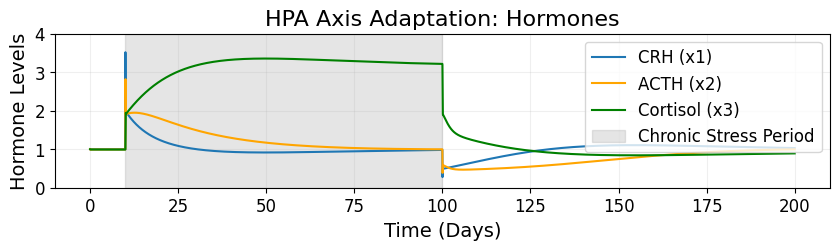

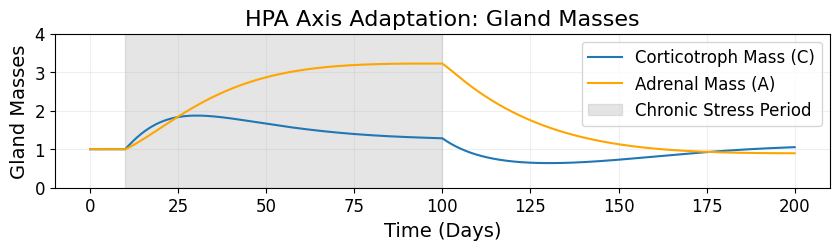

Gland mass at (rough) steady state   | C: 1.0528 | A: 0.8951


In [7]:
plt.rcdefaults()  # reset default styles

# Increase font sizes globally
plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 14,     # x and y labels
    'legend.fontsize': 12,    # legend
    'xtick.labelsize': 12,    # x tick labels
    'ytick.labelsize': 12     # y tick labels
})

# plotting
plt.figure(figsize=(10, 2))
plt.plot(t_eval/1440, sol[:, 0], label='CRH (x1)', color='tab:blue')
plt.plot(t_eval/1440, sol[:, 1], label='ACTH (x2)', color='orange')
plt.plot(t_eval/1440, sol[:, 2], label='Cortisol (x3)', color='green')
plt.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Chronic Stress Period')
plt.title("HPA Axis Adaptation: Hormones")
plt.xlabel("Time (Days)")
plt.ylabel("Hormone Levels")
plt.ylim(0, 4)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(t_eval/1440, sol[:, 3], label='Corticotroph Mass (C)', color='tab:blue')
plt.plot(t_eval/1440, sol[:, 4], label='Adrenal Mass (A)', color='orange')
plt.axvspan(D_stress, D_stop, color='gray', alpha=0.2, label='Chronic Stress Period')
plt.title("HPA Axis Adaptation: Gland Masses")
plt.xlabel("Time (Days)")
plt.ylabel("Gland Masses")
plt.legend()
plt.ylim(0, 4)
plt.grid(alpha=0.2)
plt.show()

# Extract the final values (Index -1 is the last day, which is 200)
c_ss = sol[-1, 3]
a_ss = sol[-1, 4]

print(f"Gland mass at (rough) steady state   | C: {c_ss:.4f} | A: {a_ss:.4f}")

### Comment
This reproduction matches the figures in the paper.

# Novel Extension: Melatonin-Modulated GR Resistance

In [8]:
# --- normal state (control rats) ---
# Format: [NaCl, MEL]
kd_norm_hp = {
    "hypo": [9.8, 26.9], 
    "pit": [2.2, 10.4]
}
bmax_norm_hp = {
    "hypo": [15.5, 53.1], 
    "pit": [8.2, 20.3]
}

# --- 2. rats in chronic stress state (CS treatment) ---
kd_stress_hp = {
    "hypo": [13.7, 16.5], 
    "pit": [2.5, 4.1]
}
bmax_stress_hp = {
    "hypo": [17.6, 19.3], 
    "pit": [16.6, 9.3]
}

# Helper to get the average ratio for Hypo and Pit
def get_hp_ratios(data_dict):
    return np.mean([v[1]/v[0] for v in data_dict.values()])

# KD MODIFIERS (Higher = Lower Affinity/Higher Threshold)
avg_kd_normal_hp = get_hp_ratios(kd_norm_hp)
avg_kd_stress_hp = get_hp_ratios(kd_stress_hp)

# BMAX MODIFIERS (Higher = More Receptors)
avg_bmax_normal_hp = get_hp_ratios(bmax_norm_hp)
avg_bmax_stress_hp = get_hp_ratios(bmax_stress_hp)

print(f"--- Normal --- \nKd: {avg_kd_normal_hp:.2f}, Bmax: {avg_bmax_normal_hp:.2f}")
print(f"--- Stressed --- \nKd: {avg_kd_stress_hp:.2f}, Bmax: {avg_bmax_stress_hp:.2f}")

--- Normal --- 
Kd: 3.74, Bmax: 2.95
--- Stressed --- 
Kd: 1.42, Bmax: 0.83


In [9]:
# quasi steady state concentration of cortisol at healthy adrenal mass and corticotroph mass levels = (CA)^(1/2) = 1 
# (printed earlier)
x3_threshold = (0.9624  * 0.9146)**(1/2)

print(x3_threshold)

MEL_active = True 

0.9381956299194748


In [10]:
def pGR_melatonin(x3, t, mel_on=True):
    t_days = t / 1440
    
    # Baseline modifier is 1
    mel_modifier = 1.0

    if mel_on:
        mel_modifier = avg_kd_normal_hp if x3 <= x3_threshold else avg_kd_stress_hp

    # Base feedback parameter (Example: 5.0)
    base_param = 5.0
    
    if t_days <= D_stop:
        return base_param * mel_modifier
    else:
        # Exponential recovery phase logic
        recovery_start = D_stop * 1440
        return (2.0 * mel_modifier + 3.0 * mel_modifier * np.exp(-(t - recovery_start) / tau))


In [11]:


def hpa_model_mel(y, t, mel_on):
    x1, x2, x3, C, A = y
    u_t = u(t)
    
    # receptor sensitivity
    K_t = pGR_melatonin(x3, t, mel_on=mel_on)
    
    # get smooth transition (from not stressed -> stressed state)
    receptor_density = 1.0
    if mel_on:
        receptor_density = avg_bmax_normal_hp if x3 <= x3_threshold else avg_bmax_stress_hp
    
    # as described in paper
    n = 3 
    G_x3 = receptor_density / (1.0 + (x3 / K_t)**n)
    
    # as described in paper
    M_x3 = 1.0 / x3
    
    # 5. ODEs
    dx1 = w1 * (u_t * G_x3 * M_x3 - x1)
    dx2 = w2 * (C * x1 * G_x3 - x2)
    dx3 = w3 * (A * x2 - x3)
    dC  = wC * C * (x1 - 1.0)
    dA  = wA * A * (x2 - 1.0)
    
    return [dx1, dx2, dx3, dC, dA]

In [12]:

t_eval = np.linspace(0, 200 * 1440, 10000) # 200 days * 1440 min/day, with many samples
y0 = [1.0, 1.0, 1.0, 1.0, 1.0]

# no melatonin treatment group
sol_control = odeint(hpa_model_mel, y0, t_eval, args=(False,))
# melatonin treatment group
sol_mel = odeint(hpa_model_mel, y0, t_eval, args=(True,))

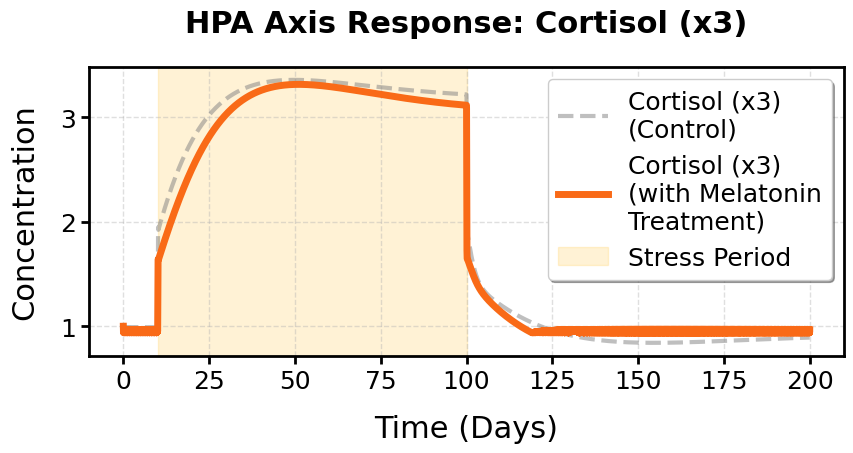

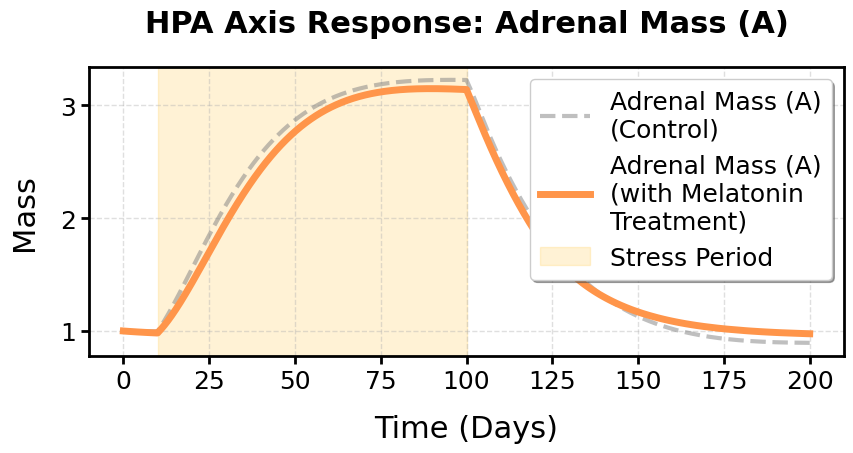

In [15]:
# custom visuals (big text, thick lines) for poster
plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'legend.fontsize': 18,
    'axes.linewidth': 2,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
})

labels = ['CRH (x1)', 'ACTH (x2)', 'Cortisol (x3)', 'Corticotroph Mass (C)', 'Adrenal Mass (A)']
colors = ['tab:blue', 'orange', '#F96A17', 'red', '#FF954A'] # theme colours
# only interested in cortisol and adrenal mass, but plot others to validate

for i in range(5):
    if(labels[i] != 'Cortisol (x3)' and labels[i] != 'Adrenal Mass (A)'): continue # only plot cortisol and adrenal mass
    plt.figure(figsize=(9, 5))

    # Plot Control
    plt.plot(t_eval/1440, sol_control[:, i],
             label=f'{labels[i]}\n(Control)',
             color='gray', linestyle='--', alpha=0.5, linewidth=3)

    # Plot Melatonin
    plt.plot(t_eval/1440, sol_mel[:, i],
             label=f'{labels[i]}\n(with Melatonin\nTreatment)',
             color=colors[i], linewidth=5)

    # Shade the stress period (Slightly darker for print contrast)
    plt.axvspan(D_stress, D_stop, color="#FFC12F", alpha=0.2, label='Stress Period')

    # Formatting
    plt.title(f"HPA Axis Response: {labels[i]}", pad=25, fontweight='bold')
    y_label = "Concentration"
    if "Mass" in labels[i]:
        y_label = "Mass"

    plt.ylabel(y_label, labelpad=15)
    plt.xlabel("Time (Days)", labelpad=15)

    # Force whole numbers on Y-axis (when possible)
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    # Make the tick marks thicker
    plt.gca().tick_params(width=2, length=6)

    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(alpha=0.4, linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()